### Loan Approval Prediction using Machine Learning
The objective of this project is to develop a machine learning classification model to predict whether a loan application will be approved or rejected. The target variable, loan status, is categorical in nature, making this a classification problem.

The model will utilize various independent variables such as applicant details (income, education, employment status), loan-related attributes (loan amount, loan term), and credit history to determine the likelihood of loan approval.

Accurate prediction of loan approval can help financial institutions automate decision-making, reduce risk, and improve the efficiency of the loan approval process.

## IMPORTING REQUIRED LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
import statsmodels.formula.api as sm
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as mt
from sklearn.metrics import f1_score, accuracy_score,precision_score,recall_score
from sklearn.model_selection import GridSearchCV

### IMPORTING DATASET

In [2]:
df = pd.read_csv("Loan_Status.csv")

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.shape

(614, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
df.drop('Loan_ID',axis=1,inplace=True)

### CHECKING DESCRIPENCY IN CATEGORICAL COLUMNS 

In [7]:
cat_df = df.select_dtypes(include='object')

In [8]:
for i in cat_df.columns:
    print(df[i].value_counts())
    print('\n')

Gender
Male      489
Female    112
Name: count, dtype: int64


Married
Yes    398
No     213
Name: count, dtype: int64


Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64


Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64


Self_Employed
No     500
Yes     82
Name: count, dtype: int64


Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64


Loan_Status
Y    422
N    192
Name: count, dtype: int64




### CHECKING MISSING VALUES 

In [9]:
(df.isnull().sum()/len(df))*100

Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [10]:
df.Credit_History.value_counts()

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64

In [11]:
df.Credit_History.mode()[0]

np.float64(1.0)

In [12]:
df.Credit_History.fillna(df.Credit_History.mode()[0],inplace=True)

In [13]:
(df.isnull().sum()/len(df))*100

Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       0.000000
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [14]:
df.Self_Employed.value_counts()

Self_Employed
No     500
Yes     82
Name: count, dtype: int64

In [15]:
df.Self_Employed.mode()[0]

'No'

In [16]:
df.Self_Employed.fillna(df.Self_Employed.mode()[0],inplace=True)

In [17]:
(df.isnull().sum()/len(df))*100

Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        0.000000
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       0.000000
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [18]:
df.dropna(inplace=True)

In [19]:
(df.isnull().sum()/len(df))*100

Gender               0.0
Married              0.0
Dependents           0.0
Education            0.0
Self_Employed        0.0
ApplicantIncome      0.0
CoapplicantIncome    0.0
LoanAmount           0.0
Loan_Amount_Term     0.0
Credit_History       0.0
Property_Area        0.0
Loan_Status          0.0
dtype: float64

In [20]:
df.duplicated().sum()

np.int64(0)

### CHECKING OUTLIERS

In [21]:
cont_df = df.select_dtypes(include='number')

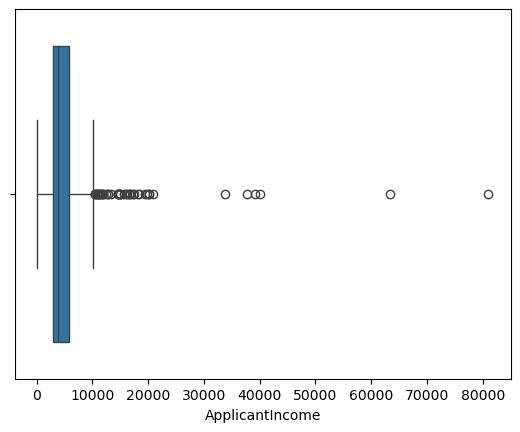

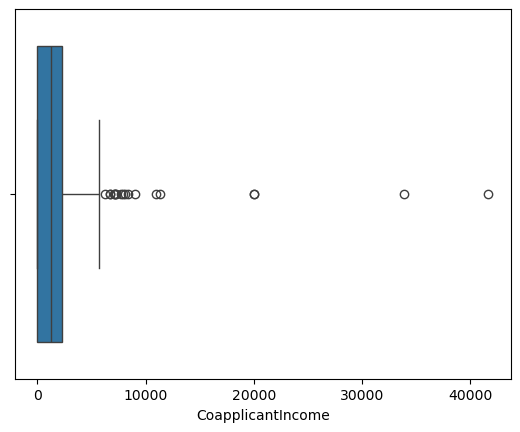

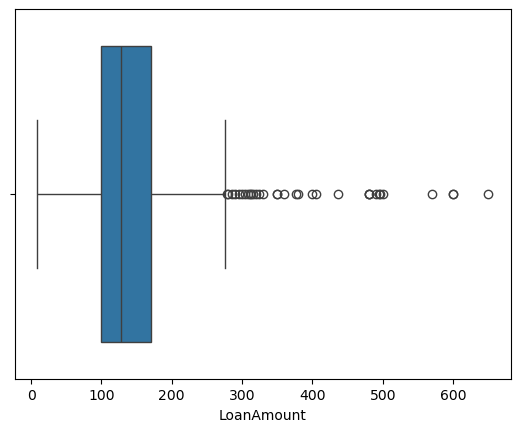

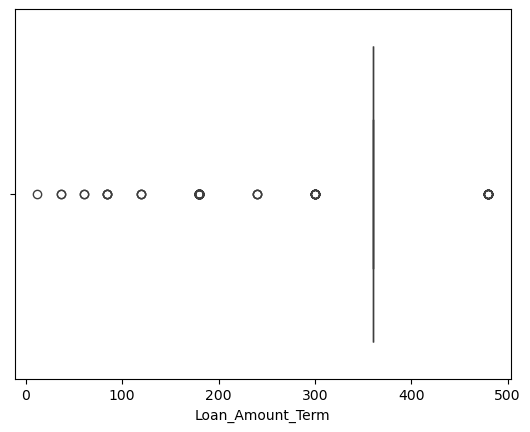

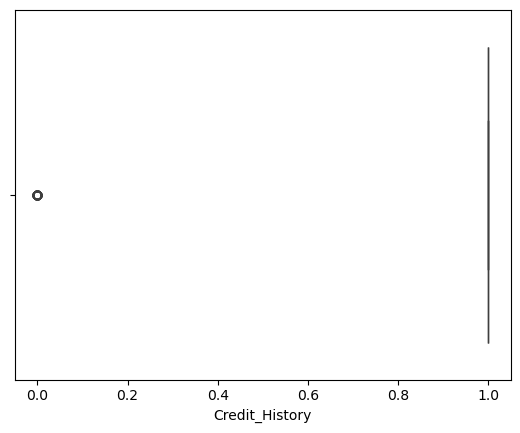

In [22]:
for i in cont_df.columns:
    sns.boxplot(data=df,x=i)
    plt.show()

In [23]:
df.Loan_Amount_Term.value_counts()

Loan_Amount_Term
360.0    473
180.0     40
480.0     13
300.0     12
84.0       4
120.0      3
240.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [24]:
cont_df.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

### outlier treatment

In [25]:
for i in ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr = q3-q1
    ur = q3 +  1.5*iqr
    lr = q1 - 1.5*iqr
    df[i]=df[i].clip(lower=lr,upper=ur)

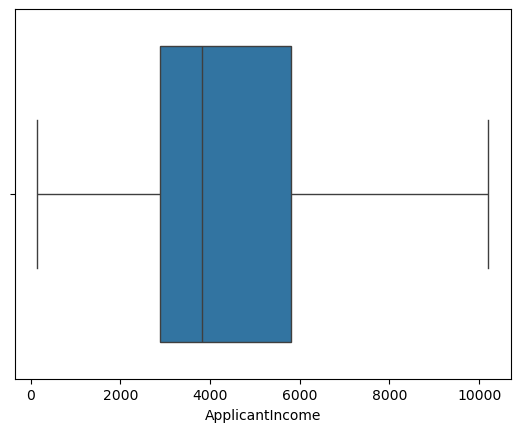

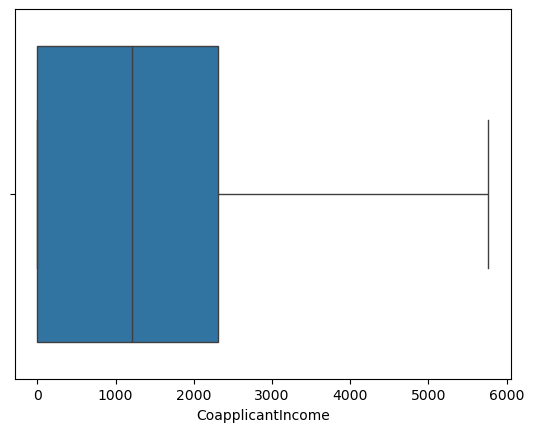

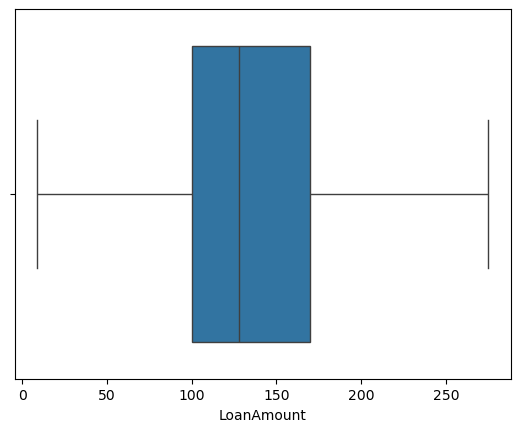

In [26]:
for i in['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']:
    sns.boxplot(data=df,x=i)
    plt.show()

### ENCODING  - ONE HOT ENCODING 

cat_df.columns

In [27]:
for i in cat_df.columns:
    print('\n')
    print('feature:',i)
    print(pd.Categorical(df[i].unique()))
    print(pd.Categorical(df[i].unique()).codes)
    df[i]=pd.Categorical(df[i]).codes
    print('\n')



feature: Gender
['Male', 'Female']
Categories (2, object): ['Female', 'Male']
[1 0]




feature: Married
['Yes', 'No']
Categories (2, object): ['No', 'Yes']
[1 0]




feature: Dependents
['1', '0', '2', '3+']
Categories (4, object): ['0', '1', '2', '3+']
[1 0 2 3]




feature: Education
['Graduate', 'Not Graduate']
Categories (2, object): ['Graduate', 'Not Graduate']
[0 1]




feature: Self_Employed
['No', 'Yes']
Categories (2, object): ['No', 'Yes']
[0 1]




feature: Property_Area
['Rural', 'Urban', 'Semiurban']
Categories (3, object): ['Rural', 'Semiurban', 'Urban']
[0 2 1]




feature: Loan_Status
['N', 'Y']
Categories (2, object): ['N', 'Y']
[0 1]





### feature selection RFE 

In [28]:
X =df.drop('Loan_Status' , axis=1)
y=df.Loan_Status 

In [29]:
model = LogisticRegression()

In [30]:
rfe = RFE(estimator=model , n_features_to_select=8).fit(X,y)

In [31]:
pd.DataFrame({'Features' : X.columns , 'Ranking' : rfe.ranking_}).sort_values(by='Ranking',ascending=True)

,Features,Ranking
0,Gender,1
1,Married,1
2,Dependents,1
3,Education,1
4,Self_Employed,1
7,LoanAmount,1
10,Property_Area,1
9,Credit_History,1
8,Loan_Amount_Term,2
5,ApplicantIncome,3


In [32]:
X = X.drop(['Loan_Amount_Term','ApplicantIncome','CoapplicantIncome'],axis=1)

### multicollinearity

In [33]:
def vif_cal(Z):
    x_var =Z
    xvar_names = Z.columns
    vif = pd.DataFrame()
    for i in range(0, xvar_names.shape[0]):
        y=x_var[xvar_names[i]]
        x = x_var[xvar_names.drop(xvar_names[i])]
        rsq =sm.ols(formula ="y~x", data =x_var).fit().rsquared
        vif = round(1/(1-rsq),2)
        print(xvar_names[i], 'VIF = ' , vif)

In [34]:
vif_cal(Z = X[['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
        'LoanAmount',
       'Credit_History', 'Property_Area']])

Gender VIF =  1.16
Married VIF =  1.29
Dependents VIF =  1.17
Education VIF =  1.05
Self_Employed VIF =  1.02
LoanAmount VIF =  1.11
Credit_History VIF =  1.01
Property_Area VIF =  1.01


### train-test-split

In [35]:
Xtrain ,Xtest ,ytrain , ytest = train_test_split(X,y,test_size=0.2 ,random_state=5)

In [36]:
num_cols = ['LoanAmount']
ss = StandardScaler()
Xtrain[num_cols] = ss.fit_transform(Xtrain[num_cols])
Xtest[num_cols] =ss.transform(Xtest[num_cols])

In [37]:
Xtrain.head()

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Credit_History,Property_Area
85,1,0,0,0,0,-0.032768,1.0,1
203,1,1,1,1,0,-0.049629,1.0,2
520,1,1,2,1,0,-1.567096,1.0,1
503,1,1,1,1,0,0.000954,1.0,0
411,1,1,0,0,0,0.371890,1.0,2


#  modelling 

In [38]:
m1 = LogisticRegression().fit(Xtrain,ytrain)

In [39]:
train_pred = m1.predict(Xtrain)
test_pred = m1.predict(Xtest)

## performance check 
### training 

In [40]:
mt.confusion_matrix(ytrain,train_pred)

array([[ 50,  78],
       [  6, 308]])

In [41]:
print(mt.classification_report(ytrain,train_pred))

              precision    recall  f1-score   support

           0       0.89      0.39      0.54       128
           1       0.80      0.98      0.88       314

    accuracy                           0.81       442
   macro avg       0.85      0.69      0.71       442
weighted avg       0.83      0.81      0.78       442



### test -Performance

In [42]:
mt.confusion_matrix(ytest,test_pred)

array([[14, 22],
       [ 1, 74]])

In [43]:
print(mt.classification_report(ytest,test_pred))

              precision    recall  f1-score   support

           0       0.93      0.39      0.55        36
           1       0.77      0.99      0.87        75

    accuracy                           0.79       111
   macro avg       0.85      0.69      0.71       111
weighted avg       0.82      0.79      0.76       111



In [44]:
train_prob=m1.predict_proba(Xtrain)[:,1]
test_prob=m1.predict_proba(Xtest)[:,1]

## custom threshold

In [45]:
threshold = np.arange(0.1,0.9,0.01)
best_thres = 0
best_score = 0

for i in threshold:
    pred = (train_prob > i).astype(int)
    score = f1_score(ytrain,pred)
    if score>best_score:
        best_score=score
   
        best_thres=i
    

In [46]:
best_score

0.8837876614060258

In [47]:
best_thres

np.float64(0.5499999999999998)

# performance check with custom threshold ((0.55)

In [48]:
train_pred1=(train_prob>=best_thres).astype(int)
test_pred1=(test_prob>=best_thres).astype(int)

In [49]:
print(mt.classification_report(ytrain,train_pred1))

              precision    recall  f1-score   support

           0       0.90      0.41      0.57       128
           1       0.80      0.98      0.88       314

    accuracy                           0.82       442
   macro avg       0.85      0.70      0.73       442
weighted avg       0.83      0.82      0.79       442



In [50]:
print(mt.classification_report(ytest,test_pred1))

              precision    recall  f1-score   support

           0       0.94      0.42      0.58        36
           1       0.78      0.99      0.87        75

    accuracy                           0.80       111
   macro avg       0.86      0.70      0.72       111
weighted avg       0.83      0.80      0.78       111



In [51]:
m1.coef_

array([[ 0.02710021,  0.53913874,  0.0185638 , -0.21204692, -0.04064083,
        -0.29517171,  3.00160678,  0.22790026]])

In [52]:
m1.intercept_

array([-2.20276377])

EXAMPLE to understand the final o/p


| Feature                | Coefficient | Interpretation                                                              |
| ---------------------- | ----------- | --------------------------------------------------------------------------- |
| **Married**            | `+0.5641`   | Being married **increases** log-odds of loan approval.                      |
| **Dependents**         | `+0.0191`   | Has **negligible effect** on loan approval.                                 |
| **Education**          | `−0.2142`   | Higher education (or whatever is coded as 1) **reduces** log-odds slightly. |
| **ApplicantIncome**    | `+0.0703`   | As income increases, the **log-odds of approval increase** slightly.        |
| **LoanAmount**         | `−0.3395`   | Higher loan amounts **reduce** log-odds of approval.                        |
| **Loan\_Amount\_Term** | `−0.0947`   | Longer loan terms **slightly reduce** chances of approval.                  |
| **Credit\_History**    | `+1.1512`   | Very **strong positive influence**; good credit history is a big boost.     |
| **Property\_Area**     | `+0.2338`   | Certain property areas may slightly **increase** approval odds.             |


# GridSearch


In [53]:
param_grid={'penalty':['l1','l2','elasticnet','none'],
           'C':[0.01,0.1,1,10],
           'solver':['saga','sag'],
           'l1_ratio':[0,0.5,1],
           'max_iter':[150,500,1000],
           'tol':[1e-4, 1e-3, 1e-2]}

grid=GridSearchCV(LogisticRegression(),param_grid,cv=5,scoring='accuracy',n_jobs=-1)

grid.fit(Xtrain,ytrain)

print('Best parameters:',grid.best_params_)
print('Best scores:',grid.best_score_)

Best parameters: {'C': 0.1, 'l1_ratio': 0, 'max_iter': 150, 'penalty': 'l1', 'solver': 'saga', 'tol': 0.0001}
Best scores: 0.8098569969356486


# performance check with best parameters 

In [54]:
m2=LogisticRegression(C= 0.1, l1_ratio=0, max_iter=150, penalty= 'l1', solver='saga', tol= 0.0001).fit(Xtrain,ytrain)

In [55]:
train_pred2=m2.predict(Xtrain)
test_pred2=m2.predict(Xtest)

In [56]:
train_prob2=m2.predict_proba(Xtrain)[:,1]
test_prob2=m2.predict_proba(Xtest)[:,1]

In [57]:
thresholds=np.arange(0.1,0.9,0.01)
best_thresh=0
best_score=0


for i in thresholds:
    pred=(train_prob2>i).astype(int)
    score=accuracy_score(ytrain,pred)
    if score>best_score:
        best_score=score
        best_thresh=i

In [58]:
print(best_score)
print(best_thresh)

0.8099547511312217
0.32999999999999985


In [59]:
train_pred3=(train_prob2>=best_thresh).astype(int)
test_pred3=(test_prob2>=best_thresh).astype(int)

# performance check 
# training 

In [60]:
print(mt.classification_report(ytrain,train_pred3))

              precision    recall  f1-score   support

           0       0.89      0.39      0.54       128
           1       0.80      0.98      0.88       314

    accuracy                           0.81       442
   macro avg       0.85      0.69      0.71       442
weighted avg       0.83      0.81      0.78       442



In [61]:
print(mt.classification_report(ytest,test_pred3))

              precision    recall  f1-score   support

           0       0.93      0.36      0.52        36
           1       0.76      0.99      0.86        75

    accuracy                           0.78       111
   macro avg       0.85      0.67      0.69       111
weighted avg       0.82      0.78      0.75       111

